# Feature Engineering and Model Development

This notebook transforms the cleaned customer dataset into machine-learning-ready features and develops multiple classification models for churn prediction. The workflow emphasizes leakage prevention, reproducibility, and fair comparison between algorithms.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display

pd.set_option("display.max_columns", None)

from sklearn.model_selection import train_test_split

## Data Processing

In [2]:
df = pd.read_csv(r"C:\Users\olive\Documents\workspace\Customer-Churn-Risk-Assessment-and-Retention-Analytics\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
).fillna(0)

df["TotalCharges"].isna().sum()

np.int64(0)

## Total Charges processing

In [4]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
).fillna(0)

df["TotalCharges"].isna().sum()
df_model = df.copy()

### Target Variable Encoding
The target variable (`Churn`) was converted from categorical labels ("Yes"/"No") to a binary representation (1/0) to enable supervised classification modelling.

- **1** → Customer churned
- **0** → Customer retained

In [5]:
df_model["Churn"] = (
    df_model["Churn"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

In [6]:
df_model.drop(columns="customerID", inplace=True)

The customer identifier uniquely identifies each customer but contains no predictive information. It is therefore removed before model development to avoid introducing meaningless identifiers into the learning process.

## Feature Engineering

In [7]:
from pandas.api.types import is_string_dtype

categorical_features = [
    col
    for col in df_model.columns
    if col != "Churn" and is_string_dtype(df_model[col])
]

numerical_features = [
    col
    for col in df_model.columns
    if col not in categorical_features + ["Churn"]
]

In [8]:
pd.DataFrame({
    "Unique Values":
    df_model[categorical_features].nunique()
}).sort_values(
    "Unique Values",
    ascending=False
)

,Unique Values
PaymentMethod,4
InternetService,3
OnlineSecurity,3
DeviceProtection,3
TechSupport,3
OnlineBackup,3
MultipleLines,3
StreamingTV,3
StreamingMovies,3
Contract,3


### Feature Cardinality

All categorical variables contain between 2 and 4 unique categories, indicating low cardinality. Consequently, one-hot encoding was selected as the encoding strategy because it preserves interpretability while avoiding artificial ordinal relationships between categorical values.

No high-cardinality features requiring target encoding or embedding techniques were identified.

In [9]:
X = df_model.drop(
    columns="Churn"
)

y = df_model["Churn"]

## Preventing Data Leakage

Several design decisions were made to ensure unbiased model evaluation:

- The train/test split is performed before fitting any preprocessing transformations.
- Scaling parameters are learned only from the training data.
- Categorical encoding is fitted exclusively on the training set.
- Hyperparameter tuning uses cross-validation within the training data.
- The independent test set is used only once for final evaluation.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Machine Learning Pipeline

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [13]:
def build_pipeline(model):
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

In [14]:
log_reg_pipeline = build_pipeline(
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )
)

In [15]:
log_reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [16]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC": average_precision_score(y_test, y_proba)
    }

In [17]:
results = []

results.append(
    evaluate_model(
        log_reg_pipeline,
        X_test,
        y_test,
        "Logistic Regression"
    )
)

pd.DataFrame(results).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.738,0.504,0.783,0.614,0.842,0.633


## Baseline Model Performance

The Logistic Regression model provides a strong and interpretable baseline for churn prediction. To address the class imbalance observed during exploratory analysis, balanced class weights were applied during training.

Although this approach results in a modest reduction in overall accuracy, it substantially improves recall, enabling the model to identify a larger proportion of customers at risk of churning.

From a business perspective, correctly identifying potential churners is more valuable than maximizing overall accuracy, since missed churn cases represent lost opportunities for proactive retention.

In [18]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=4,
        learning_rate=0.05,
        loss_function="Logloss",
        verbose=False,
        random_state=42
    )
}

In [19]:
model_results = []

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")

    pipeline = build_pipeline(model)
    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    result = evaluate_model(
        pipeline,
        X_test,
        y_test,
        name
    )

    model_results.append(result)

results_df = (
    pd.DataFrame(model_results)
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)

results_df.round(3)

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training CatBoost...


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,CatBoost,0.808,0.671,0.540,0.599,0.845,0.662
1,Random Forest,0.757,0.528,0.794,0.635,0.843,0.652
2,XGBoost,0.798,0.648,0.527,0.581,0.842,0.652
3,Logistic Regression,0.738,0.504,0.783,0.614,0.842,0.633


## Model Benchmarking

Multiple classification models were compared using the same preprocessing pipeline and train/test split. This ensures that performance differences are driven by model behaviour rather than inconsistent preprocessing.

The models evaluated include:

- Logistic Regression as an interpretable baseline
- Random Forest as a non-linear ensemble model
- XGBoost as a gradient boosting model
- CatBoost as a boosting model designed to handle categorical patterns effectively

## Model Comparison

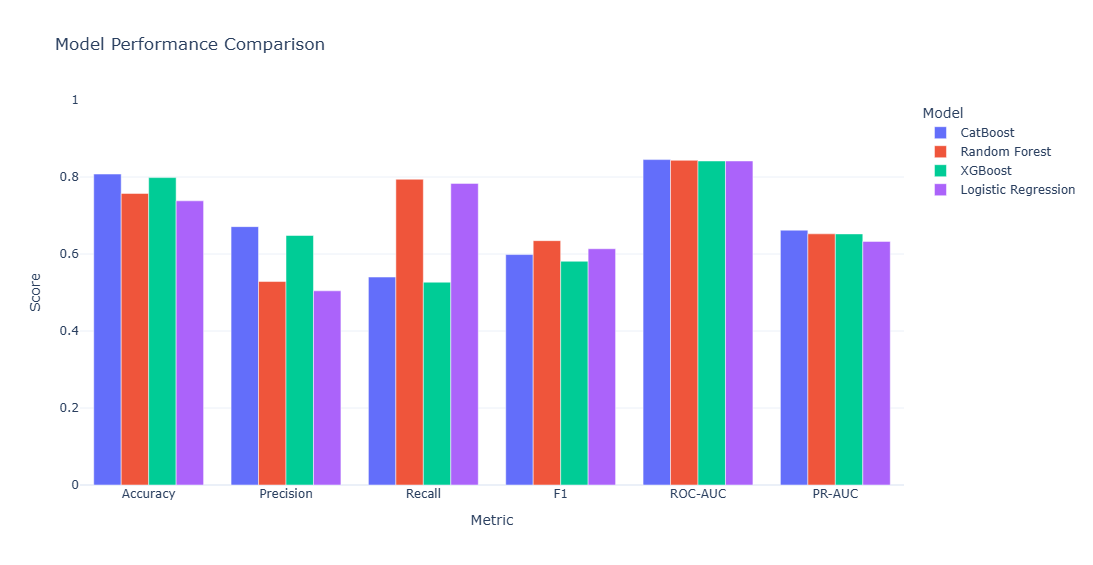

In [20]:
results_long = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

fig = px.bar(
    results_long,
    x="Metric",
    y="Score",
    color="Model",
    barmode="group",
    template="plotly_white",
    title="Model Performance Comparison"
)

fig.update_layout(
    width=1100,
    height=550,
    yaxis=dict(range=[0,1])
)

fig.show()

### Model Comparison

No single model dominates across every evaluation metric.

- Logistic Regression achieves strong recall while remaining highly interpretable.
- Random Forest provides the highest recall and F1-score, making it suitable when identifying as many churning customers as possible is the primary objective.
- CatBoost achieves the highest precision, ROC-AUC and PR-AUC, making it the strongest overall probabilistic classifier.
- XGBoost performs competitively but offers no clear advantage over CatBoost on this dataset.

## Model Selection Summary

| Business Objective      | Recommended Model   | Reason                                                  |
| ----------------------- | ------------------- | ------------------------------------------------------- |
| Highest Recall          | Random Forest       | Identifies the largest proportion of churning customers |
| Highest Precision       | CatBoost            | Minimizes unnecessary retention actions                 |
| Highest Overall Ranking | CatBoost            | Best ROC-AUC and PR-AUC                                 |
| Most Interpretable      | Logistic Regression | Transparent coefficients and easy explanation           |


## Why Accuracy Alone Is Insufficient

Customer churn prediction is an imbalanced classification problem. A model that predicts every customer as retained would achieve high accuracy while failing to identify customers who are most likely to leave.

For this reason, model evaluation focuses primarily on:

- Recall
- Precision
- PR-AUC
- ROC-AUC

rather than overall accuracy.

In [22]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(trained_models["CatBoost"], "../models/catboost_pipeline.pkl")
joblib.dump(trained_models["Random Forest"], "../models/random_forest_pipeline.pkl")
joblib.dump(trained_models["Logistic Regression"], "../models/logistic_regression_pipeline.pkl")
X_test.to_csv("../data/processed/X_test.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)